In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

print("All libraries imported successfully")

All libraries imported successfully


# Advanced Pandas, Visualization and SQL Essentials

## Objective
This notebook demonstrates:
- Advanced Pandas operations
- Data cleaning
- GroupBy and aggregation
- Merge and joins
- Pivot tables
- Data visualization
- SQLite database operations
- SQL queries using Python

In [2]:
sales_data = {
    "Customer": ["Aman", "Priya", "Rahul", "Sneha", "Aman", "Priya", "Rahul", "Sneha"],
    "Product": ["Laptop", "Phone", "Tablet", "Laptop", "Tablet", "Phone", "Laptop", "Tablet"],
    "Category": ["Electronics", "Electronics", "Electronics", "Electronics",
                 "Electronics", "Electronics", "Electronics", "Electronics"],
    "Region": ["North", "South", "East", "West", "North", "South", "East", "West"],
    "Sales": [55000, 30000, 20000, 60000, 25000, 32000, 58000, 22000],
    "Quantity": [2, 3, 1, 2, 1, 2, 3, 1]
}

df = pd.DataFrame(sales_data)

df

,Customer,Product,Category,Region,Sales,Quantity
0,Aman,Laptop,Electronics,North,55000,2
1,Priya,Phone,Electronics,South,30000,3
2,Rahul,Tablet,Electronics,East,20000,1
3,Sneha,Laptop,Electronics,West,60000,2
4,Aman,Tablet,Electronics,North,25000,1
5,Priya,Phone,Electronics,South,32000,2
6,Rahul,Laptop,Electronics,East,58000,3
7,Sneha,Tablet,Electronics,West,22000,1


In [3]:
df.to_csv("sales_data.csv", index=False)

print("sales_data.csv created successfully")

sales_data.csv created successfully


## Task 1 - Basic Inspection

In [4]:
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Info:")
print(df.info())

  Customer Product     Category Region  Sales  Quantity
0     Aman  Laptop  Electronics  North  55000         2
1    Priya   Phone  Electronics  South  30000         3
2    Rahul  Tablet  Electronics   East  20000         1
3    Sneha  Laptop  Electronics   West  60000         2
4     Aman  Tablet  Electronics  North  25000         1

Dataset Shape:
(8, 6)

Column Names:
Index(['Customer', 'Product', 'Category', 'Region', 'Sales', 'Quantity'], dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Customer  8 non-null      object
 1   Product   8 non-null      object
 2   Category  8 non-null      object
 3   Region    8 non-null      object
 4   Sales     8 non-null      int64 
 5   Quantity  8 non-null      int64 
dtypes: int64(2), object(4)
memory usage: 516.0+ bytes
None


## Task 2 - Handling Missing Values

In [5]:
# Introduce missing values
df_missing = df.copy()

df_missing.loc[2, "Sales"] = np.nan
df_missing.loc[5, "Quantity"] = np.nan

print("Dataset with Missing Values:")
print(df_missing)

print("\nMissing Values Count:")
print(df_missing.isnull().sum())

print("\nAfter fillna():")
filled_df = df_missing.fillna(0)
print(filled_df)

Dataset with Missing Values:
  Customer Product     Category Region    Sales  Quantity
0     Aman  Laptop  Electronics  North  55000.0       2.0
1    Priya   Phone  Electronics  South  30000.0       3.0
2    Rahul  Tablet  Electronics   East      NaN       1.0
3    Sneha  Laptop  Electronics   West  60000.0       2.0
4     Aman  Tablet  Electronics  North  25000.0       1.0
5    Priya   Phone  Electronics  South  32000.0       NaN
6    Rahul  Laptop  Electronics   East  58000.0       3.0
7    Sneha  Tablet  Electronics   West  22000.0       1.0

Missing Values Count:
Customer    0
Product     0
Category    0
Region      0
Sales       1
Quantity    1
dtype: int64

After fillna():
  Customer Product     Category Region    Sales  Quantity
0     Aman  Laptop  Electronics  North  55000.0       2.0
1    Priya   Phone  Electronics  South  30000.0       3.0
2    Rahul  Tablet  Electronics   East      0.0       1.0
3    Sneha  Laptop  Electronics   West  60000.0       2.0
4     Aman  Tablet  El

## Task 3 - GroupBy and Aggregation

In [6]:
grouped = df.groupby("Region")["Sales"].sum()

print("Total Sales by Region:")
print(grouped)

average_sales = df.groupby("Product")["Sales"].mean()

print("\nAverage Sales by Product:")
print(average_sales)

Total Sales by Region:
Region
East     78000
North    80000
South    62000
West     82000
Name: Sales, dtype: int64

Average Sales by Product:
Product
Laptop    57666.666667
Phone     31000.000000
Tablet    22333.333333
Name: Sales, dtype: float64


## Task 4 - Merge DataFrames

In [7]:
customer_data = {
    "Customer": ["Aman", "Priya", "Rahul", "Sneha"],
    "Age": [21, 22, 23, 21]
}

customer_df = pd.DataFrame(customer_data)

merged_df = pd.merge(df, customer_df, on="Customer")

print(merged_df)

  Customer Product     Category Region  Sales  Quantity  Age
0     Aman  Laptop  Electronics  North  55000         2   21
1    Priya   Phone  Electronics  South  30000         3   22
2    Rahul  Tablet  Electronics   East  20000         1   23
3    Sneha  Laptop  Electronics   West  60000         2   21
4     Aman  Tablet  Electronics  North  25000         1   21
5    Priya   Phone  Electronics  South  32000         2   22
6    Rahul  Laptop  Electronics   East  58000         3   23
7    Sneha  Tablet  Electronics   West  22000         1   21


## Task 5 - Pivot Table

In [8]:
pivot = pd.pivot_table(
    df,
    values="Sales",
    index="Region",
    columns="Product",
    aggfunc="sum"
)

print(pivot)

Product   Laptop    Phone   Tablet
Region                            
East     58000.0      NaN  20000.0
North    55000.0      NaN  25000.0
South        NaN  62000.0      NaN
West     60000.0      NaN  22000.0


## Task 6 - Data Visualization

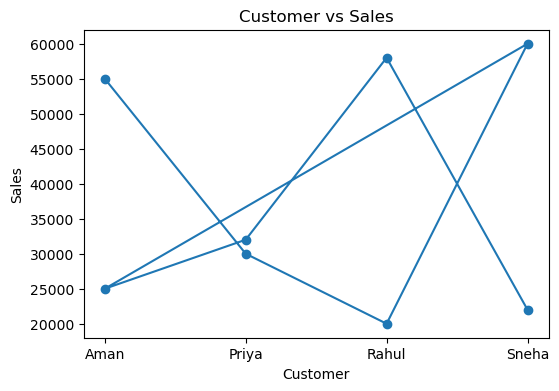

In [9]:
plt.figure(figsize=(6,4))

plt.plot(df["Customer"], df["Sales"], marker='o')

plt.title("Customer vs Sales")
plt.xlabel("Customer")
plt.ylabel("Sales")

plt.show()

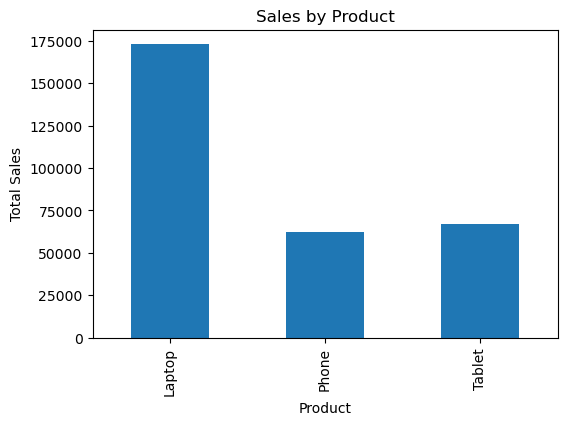

In [10]:
sales_by_product = df.groupby("Product")["Sales"].sum()

plt.figure(figsize=(6,4))

sales_by_product.plot(kind="bar")

plt.title("Sales by Product")
plt.xlabel("Product")
plt.ylabel("Total Sales")

plt.show()

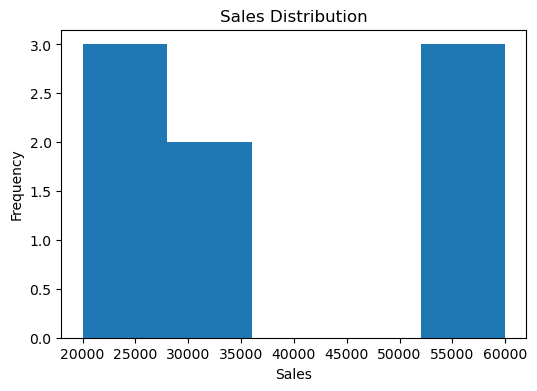

In [11]:
plt.figure(figsize=(6,4))

plt.hist(df["Sales"], bins=5)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

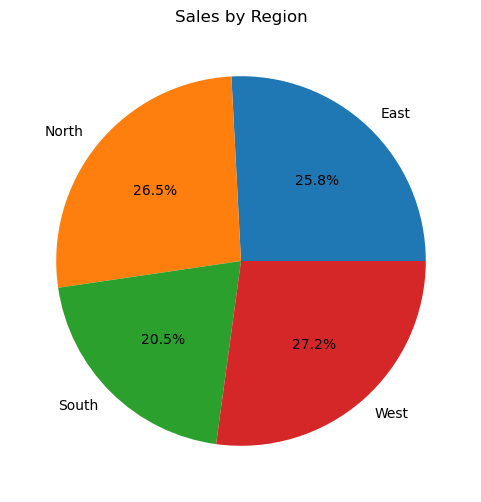

In [12]:
region_sales = df.groupby("Region")["Sales"].sum()

plt.figure(figsize=(6,6))

plt.pie(region_sales, labels=region_sales.index, autopct='%1.1f%%')

plt.title("Sales by Region")

plt.show()

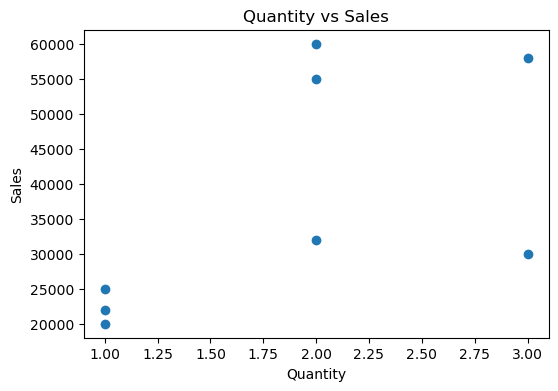

In [13]:
plt.figure(figsize=(6,4))

plt.scatter(df["Quantity"], df["Sales"])

plt.title("Quantity vs Sales")
plt.xlabel("Quantity")
plt.ylabel("Sales")

plt.show()

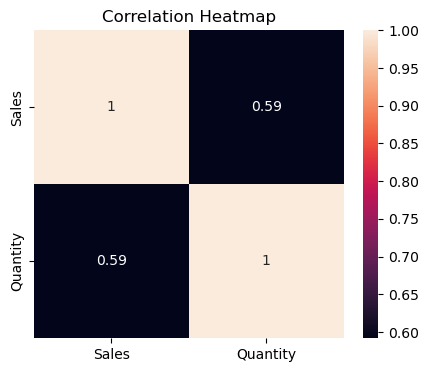

In [14]:
correlation = df[["Sales", "Quantity"]].corr()

plt.figure(figsize=(5,4))

sns.heatmap(correlation, annot=True)

plt.title("Correlation Heatmap")

plt.show()

## Task 7 - SQLite Database and SQL Queries

In [15]:
conn = sqlite3.connect("sales_data.db")

df.to_sql("sales", conn, if_exists="replace", index=False)

print("Database and table created successfully")

Database and table created successfully


In [16]:
query = "SELECT * FROM sales"

result = pd.read_sql(query, conn)

result

,Customer,Product,Category,Region,Sales,Quantity
0,Aman,Laptop,Electronics,North,55000,2
1,Priya,Phone,Electronics,South,30000,3
2,Rahul,Tablet,Electronics,East,20000,1
3,Sneha,Laptop,Electronics,West,60000,2
4,Aman,Tablet,Electronics,North,25000,1
5,Priya,Phone,Electronics,South,32000,2
6,Rahul,Laptop,Electronics,East,58000,3
7,Sneha,Tablet,Electronics,West,22000,1


### SQL Queries

In [17]:
query1 = """
SELECT SUM(Sales) AS Total_Sales
FROM sales
"""

print(pd.read_sql(query1, conn))

   Total_Sales
0       302000


In [18]:
query2 = """
SELECT Product, AVG(Sales) AS Average_Sales
FROM sales
GROUP BY Product
"""

print(pd.read_sql(query2, conn))

  Product  Average_Sales
0  Laptop   57666.666667
1   Phone   31000.000000
2  Tablet   22333.333333


In [19]:
query3 = """
SELECT *
FROM sales
ORDER BY Sales DESC
LIMIT 1
"""

print(pd.read_sql(query3, conn))

  Customer Product     Category Region  Sales  Quantity
0    Sneha  Laptop  Electronics   West  60000         2


In [20]:
query4 = """
SELECT *
FROM sales
WHERE Sales > 30000
"""

print(pd.read_sql(query4, conn))

  Customer Product     Category Region  Sales  Quantity
0     Aman  Laptop  Electronics  North  55000         2
1    Sneha  Laptop  Electronics   West  60000         2
2    Priya   Phone  Electronics  South  32000         2
3    Rahul  Laptop  Electronics   East  58000         3


In [21]:
query5 = """
SELECT Region, SUM(Quantity) AS Total_Quantity
FROM sales
GROUP BY Region
"""

print(pd.read_sql(query5, conn))

  Region  Total_Quantity
0   East               4
1  North               3
2  South               5
3   West               3


## Pandas vs SQL

### Pandas
- Best for in-memory data analysis
- Easy visualization integration
- Flexible for machine learning workflows

### SQL
- Best for database operations
- Efficient for large-scale structured data
- Useful for filtering and aggregation directly in databases